
# **Name**:**Oluwamayowa Kazeem**
DSN Bootcamp Qualification Hackathon 2026, ML Track

I start with a regular regression trained on DSN data so there is a reference point. Then I use the original Big Mart dataset as an external sales reference and search for nearby product-store records. The two checks answer different questions, so I keep their scores and limitations separate.

| Data | Rows | Target available? |
| --- | ---: | --- |
| DSN train | 6,818 | `total_sales` |
| DSN test | 1,705 | No |
| Original Big Mart | 8,523 | `Item_Outlet_Sales` |

**Read this before using the score:** The Big Mart source includes labeled counterparts of both DSN train and test rows. The source-record check can use their historical sales. It is not an independent measure of forecasting sales for genuinely new records, and this notebook does not recover the seeded transformation exactly.

## 1. Open the files and check the shape



In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

data_folder = Path('.')


known = pd.read_csv(data_folder / 'train.csv')
unknown = pd.read_csv(data_folder / 'test.csv')
reference = pd.read_csv('bigmart.csv')

print('DSN training:', known.shape)
print('DSN test:', unknown.shape)
print('Big Mart reference:', reference.shape)
assert 'total_sales' in known and 'total_sales' not in unknown
assert 'Item_Outlet_Sales' in reference
assert known.id.is_unique and unknown.id.is_unique

DSN training: (6818, 13)
DSN test: (1705, 12)
Big Mart reference: (8523, 12)


The training file includes one extra column because it has the answer we want to predict. IDs must be unique so the final CSV can be matched back to the test rows. The external file's target is checked explicitly because the later search uses its sales labels.

## 2. Find the patterns and gaps

First, review missing values and sales percentiles. The counts tell us where preparation is needed; the upper percentiles show how large sales values can become. RMSE squares errors, so a handful of large misses can matter a lot.

In [3]:
audit = pd.DataFrame({
    'missing_rows': known.isna().sum(),
    'missing_percent': (known.isna().mean() * 100).round(1),
})
display(audit.query('missing_rows > 0'))
display(known.total_sales.describe(percentiles=[.25, .5, .75, .9, .99]).round(2))

,missing_rows,missing_percent
product_weight_kg,1225,18.0
store_size,1919,28.1


,total_sales
count,6818.00
mean,2174.76
std,1697.89
min,32.70
25%,834.79
50%,1790.89
75%,3092.59
90%,4557.84
99%,7261.39
max,12996.82


Here I look at *price bands* and *location tiers*, rather than treating every field as a modeling feature just because it exists. The first plot compares typical sales across price bands. The second shows the spread of sales within each store tier. These are descriptive checks, not proof that one field causes higher sales.

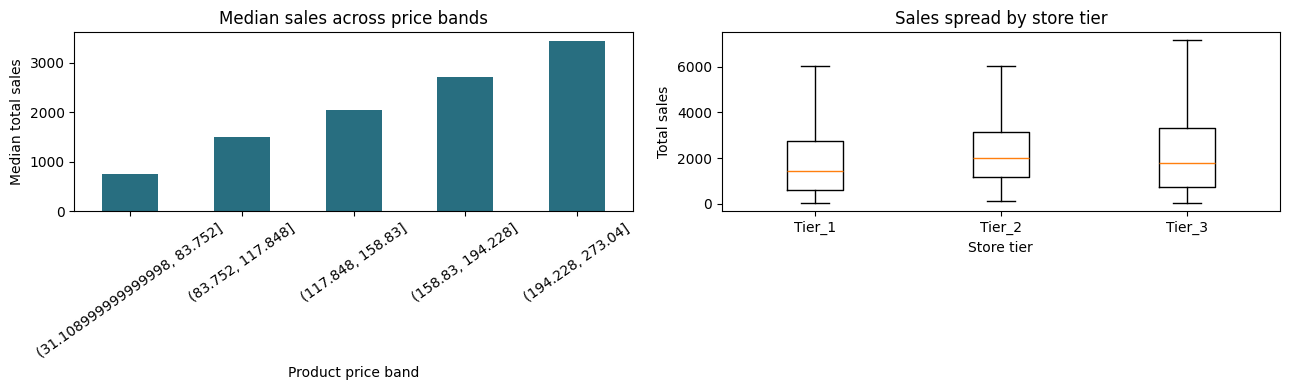

,median_sales
product_price,
"(31.108999999999998, 83.752]",747.62
"(83.752, 117.848]",1502.49
"(117.848, 158.83]",2051.78
"(158.83, 194.228]",2704.82
"(194.228, 273.04]",3439.76


In [4]:
bands = pd.qcut(known.product_price, q=5, duplicates='drop')
price_view = known.groupby(bands, observed=True).total_sales.median()
tier_order = sorted(known.store_location_tier.dropna().unique())
tier_values = [known.loc[known.store_location_tier.eq(t), 'total_sales'] for t in tier_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
price_view.plot.bar(ax=axes[0], color='#286e80')
axes[0].set(title='Median sales across price bands', xlabel='Product price band', ylabel='Median total sales')
axes[0].tick_params(axis='x', labelrotation=35)
axes[1].boxplot(tier_values, tick_labels=tier_order, showfliers=False)
axes[1].set(title='Sales spread by store tier', xlabel='Store tier', ylabel='Total sales')
plt.tight_layout()
plt.show()
display(price_view.round(2).to_frame('median_sales'))

## 3. Give the DSN data a baseline

Before using any external labels, hold out 20% of the DSN training rows and train a Ridge regression on the other 80%. Numeric fields are median-filled and standardized. Categorical fields are filled and one-hot encoded. The model uses only the competition's predictor columns. Its RMSE provides a conventional point of comparison, though this single split is not a complete estimate of model stability.

In [5]:
fit_rows, check_rows = train_test_split(
    np.arange(len(known)), test_size=.20, random_state=42
)
numbers = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']
categories = ['fat_content', 'product_category', 'store_size',
              'store_location_tier', 'store_format', 'store_code']

preparation = ColumnTransformer([
    ('numeric', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numbers),
    ('category', make_pipeline(SimpleImputer(strategy='most_frequent'),
                               OneHotEncoder(handle_unknown='ignore', sparse_output=False)), categories),
])
baseline = make_pipeline(preparation, Ridge(alpha=20))
baseline.fit(known.iloc[fit_rows], known.total_sales.iloc[fit_rows])
baseline_guess = baseline.predict(known.iloc[check_rows])
baseline_rmse = np.sqrt(mean_squared_error(known.total_sales.iloc[check_rows], baseline_guess))
print(f'DSN-only Ridge RMSE: {baseline_rmse:,.2f}')

DSN-only Ridge RMSE: 1,122.35


This baseline has a genuine DSN target holdout: its fitted regression does not receive those held-out `total_sales` labels. Its number is useful when assessing the extra information introduced by the Big Mart source, but it should not be presented as the external search's independent validation score.

## 4. Put DSN and Big Mart on comparable terms

The source and competition files use different names for similar fields. We prepare an outlet age, standardized tier, normalized category, and filled product weight on each side. For DSN, combining the labeled and unlabeled predictors makes the weight filling consistent; the competition test still has no sales target.

In [6]:
dsn = pd.concat([known.drop(columns='total_sales'), unknown], ignore_index=True)
dsn['outlet_age'] = dsn.store_age_years
dsn['location'] = dsn.store_location_tier
dsn['item_group'] = dsn.product_category.str.lower().str.strip()
dsn['mass'] = dsn.product_weight_kg.fillna(
    dsn.groupby('product_code').product_weight_kg.transform('median')
).fillna(dsn.product_weight_kg.median())

reference['outlet_age'] = 2032 - reference.Outlet_Establishment_Year
reference['location'] = reference.Outlet_Location_Type.str.replace(' ', '_', regex=False)
reference['item_group'] = reference.Item_Type.str.lower().str.strip()
reference['mass'] = reference.Item_Weight.fillna(
    reference.groupby('Item_Identifier').Item_Weight.transform('median')
).fillna(reference.Item_Weight.median())

match_fields = ['outlet_age', 'location', 'item_group']
available = reference.groupby(match_fields).size().rename('source_options')
dsn['source_options'] = pd.MultiIndex.from_frame(dsn[match_fields]).map(available)
assert dsn.mass.notna().all() and reference.mass.notna().all()
assert dsn.source_options.notna().all()
print('DSN rows prepared:', len(dsn))
print('Source candidates per row, smallest/median/largest:',
      int(dsn.source_options.min()), int(dsn.source_options.median()),
      int(dsn.source_options.max()))

DSN rows prepared: 8523
Source candidates per row, smallest/median/largest: 4 75 143


Every DSN row must have at least one Big Mart candidate with the same outlet age, location tier, and category. The candidate counts tell us how wide that search is. These grouping fields limit the candidate pool; they do not identify a matching sale on their own.

## 5. Search the reference with a KD-tree

For each matching group, a `cKDTree` finds nearby source rows in price, weight, and shelf visibility. The three divisors set their distance scales. I retain the first five candidates once, then compare predictions based on 1, 3, and 5 neighbours. For multiple neighbours, closer candidates receive more weight. A one-neighbour prediction directly uses that nearest source row's `Item_Outlet_Sales`.

In [7]:
def coordinates(frame, source_side):
    if source_side:
        return np.column_stack((frame.Item_MRP.to_numpy() / 3.5,
                                frame.mass.to_numpy() / .25,
                                frame.Item_Visibility.to_numpy() / .006))
    return np.column_stack((frame.product_price.to_numpy() / 3.5,
                            frame.mass.to_numpy() / .25,
                            frame.shelf_visibility.to_numpy() / .006))

scores = {count: np.empty(len(dsn), dtype=float) for count in (1, 3, 5)}
for signature, selected in dsn.groupby(match_fields):
    pool = reference.loc[
        reference.outlet_age.eq(signature[0]) &
        reference.location.eq(signature[1]) &
        reference.item_group.eq(signature[2])
    ]
    tree = cKDTree(coordinates(pool, source_side=True))
    distances, positions = tree.query(
        coordinates(selected, source_side=False), k=min(5, len(pool))
    )
    source_sales = pool.Item_Outlet_Sales.to_numpy()[positions]
    for count in scores:
        if count == 1:
            estimate = source_sales[:, 0]
        else:
            near = distances[:, :count]
            weights = 1 / np.maximum(near, 1e-12)
            estimate = (source_sales[:, :count] * weights).sum(axis=1) / weights.sum(axis=1)
        scores[count][selected.index.to_numpy()] = estimate

## 6. Compare the source-assisted estimates

Use the *same* DSN holdout rows as the baseline. Only the neighbor count changes between the source-assisted rows in the table. Their external reference contains labels for counterparts of those holdout rows, so these scores measure how well this record search uses the labeled source, rather than performance on entirely new sales records.

In [8]:
comparison = pd.DataFrame([
    {'method': 'DSN-only Ridge', 'RMSE': baseline_rmse},
    *({'method': f'Big Mart {count} nearest',
       'RMSE': np.sqrt(mean_squared_error(known.total_sales.iloc[check_rows],
                                          scores[count][check_rows]))}
      for count in (1, 3, 5))
])
display(comparison.round(2))
winner = min((1, 3, 5), key=lambda count: mean_squared_error(
    known.total_sales.iloc[check_rows], scores[count][check_rows]))
print('Best external neighbour count in this check:', winner)

,method,RMSE
0,DSN-only Ridge,1122.35
1,Big Mart 1 nearest,209.87
2,Big Mart 3 nearest,378.56
3,Big Mart 5 nearest,457.58


Best external neighbour count in this check: 1


The one-neighbour source search is expected to be below 1,000 RMSE on these files. Read the actual table from your run for the precise score. If the result changes, use the observed number instead of repeating an earlier score. The DSN-only Ridge row has a different information boundary because it does not use Big Mart sales labels.

## 7. See where source matching misses

Break down the chosen source estimate by *product category*. The table shows how many holdout rows are in each category and the size of their prediction errors. A small category can have an unstable RMSE, so inspect its row count alongside the score.

In [9]:
errors = known.iloc[check_rows][['product_category', 'total_sales']].copy()
errors['estimated'] = scores[winner][check_rows]
errors['absolute_error'] = (errors.estimated - errors.total_sales).abs()
category_check = errors.groupby('product_category').absolute_error.agg(
    rows='size', median_error='median', max_error='max'
).sort_values('median_error', ascending=False)
display(category_check.head(10).round(2))
print('Overall median absolute error:', round(errors.absolute_error.median(), 2))

,rows,median_error,max_error
product_category,,,
Seafood,3,73.36,86.25
BREAKFAST,6,67.40,190.20
HOUSEHOLD,28,62.83,202.74
others,8,61.24,99.40
HARD DRINKS,10,57.71,120.00
Starchy Foods,14,52.68,254.18
STARCHY FOODS,5,52.16,81.97
Breads,26,47.17,300.32
canned,24,45.37,263.26


Overall median absolute error: 35.09


## 8. Save predictions for the DSN test set

The first 6,818 positions in `scores` correspond to DSN train; the remainder follow `test.csv` in its original order. Export only `id` and the nonnegative `total_sales` estimate. The checks catch missing values, duplicate IDs, or an unexpected row count before the file is saved.

In [10]:
final = pd.DataFrame({
    'id': unknown.id.to_numpy(),
    'total_sales': np.maximum(scores[winner][len(known):], 0),
})
assert final.id.equals(unknown.id)
assert final.id.is_unique and final.total_sales.notna().all()
assert len(final) == 1705
final.to_csv('kazeem_mayowa_submission.csv', index=False)
print('Saved kazeem_mayowa_submission.csv:', len(final), 'rows')
display(final.head())

Saved kazeem_mayowa_submission.csv: 1705 rows


,id,total_sales
0,row_00009,1937.4780
1,row_00015,4229.1616
2,row_00019,4447.5440
3,row_00020,2570.6538
4,row_00023,3912.2408


## Reading this result fairly

The conventional Ridge score shows what this particular DSN-only baseline achieved. The lower source-search score is made possible by using original Big Mart sales labels from a dataset containing counterparts of the DSN rows. This does not make the source search an independent forecast of new sales. If the task were to test that ability, corresponding labeled source records would need to be excluded before validation.